In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('mps' if torch.backends.mps.is_available() 
                       else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print("All imports successful!")

Device: mps
PyTorch version: 2.11.0
All imports successful!


In [2]:
# Load feature matrix
features = pd.read_csv("../results/metrics/features_weekly.csv")

# Define feature columns
FEATURE_COLS = [
    'weekly_total_clicks',
    'active_days',
    'content_diversity',
    'forum_posts',
    'forum_replies',
    'quiz_attempts',
    'resource_views',
    'night_activity',
    'days_since_login',
    'inactive_weeks_count'
]

print(f"Features loaded: {features.shape}")
print(f"Unique students: {features['id_student'].nunique():,}")
print(f"Weeks: {features['week'].nunique()}")
print(f"Feature columns: {len(FEATURE_COLS)}")

Features loaded: (324465, 15)
Unique students: 26,050
Weeks: 17
Feature columns: 10


In [3]:
# Split each student data into:
# Baseline = first 3 weeks (weeks 0,1,2) = personal normal
# Monitoring = remaining weeks (weeks 3-16)

print("Creating personalized baseline splits...")

BASELINE_WEEKS = 3

baseline = features[features['week'] < BASELINE_WEEKS].copy()
monitoring = features[features['week'] >= BASELINE_WEEKS].copy()

print(f"Baseline records:   {len(baseline):,}")
print(f"Monitoring records: {len(monitoring):,}")
print(f"Baseline weeks:     {sorted(baseline['week'].unique())}")
print(f"Monitoring weeks:   {sorted(monitoring['week'].unique())[:5]}...")

# Check students in both sets
baseline_students = set(baseline['id_student'].unique())
monitoring_students = set(monitoring['id_student'].unique())
common_students = baseline_students & monitoring_students

print(f"\nStudents in baseline:   {len(baseline_students):,}")
print(f"Students in monitoring: {len(monitoring_students):,}")
print(f"Students in both:       {len(common_students):,}")

Creating personalized baseline splits...
Baseline records:   73,982
Monitoring records: 250,483
Baseline weeks:     [np.int64(0), np.int64(1), np.int64(2)]
Monitoring weeks:   [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]...

Students in baseline:   25,512
Students in monitoring: 24,064
Students in both:       23,526


In [4]:
# Normalize using per-student StandardScaler
# Fitted on baseline only, applied to both baseline and monitoring

print("Normalizing features per student baseline...")

from sklearn.preprocessing import StandardScaler

# Store scalers per student
scalers = {}
baseline_normalized = []
monitoring_normalized = []

# Use common students only
students = list(common_students)

for student_id in students:
    # Get baseline data for this student
    s_baseline = baseline[
        baseline['id_student'] == student_id
    ][FEATURE_COLS].values
    
    # Get monitoring data for this student
    s_monitoring = monitoring[
        monitoring['id_student'] == student_id
    ][FEATURE_COLS].values
    
    # Fit scaler on baseline only
    scaler = StandardScaler()
    s_baseline_scaled = scaler.fit_transform(s_baseline)
    s_monitoring_scaled = scaler.transform(s_monitoring)
    
    # Store
    scalers[student_id] = scaler
    baseline_normalized.append(s_baseline_scaled)
    monitoring_normalized.append(s_monitoring_scaled)

print(f"Scalers created: {len(scalers):,}")
print(f"Baseline normalized: {len(baseline_normalized)} students")
print(f"Monitoring normalized: {len(monitoring_normalized)} students")
print("\nNormalization complete!")

Normalizing features per student baseline...
Scalers created: 23,526
Baseline normalized: 23526 students
Monitoring normalized: 23526 students

Normalization complete!


In [5]:
# Define VAE Model
class VAE(nn.Module):
    def __init__(self, input_dim=10, latent_dim=6):
        super(VAE, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        # Latent space
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar

def vae_loss(reconstructed, original, mu, logvar, beta=0.1):
    # Reconstruction loss
    recon_loss = nn.MSELoss()(reconstructed, original)
    # KL divergence
    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

# Test architecture
model = VAE(input_dim=10, latent_dim=6)
print("VAE Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

VAE Architecture:
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=16, out_features=6, bias=True)
  (fc_logvar): Linear(in_features=16, out_features=6, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)

Total parameters: 2,070


In [7]:
# Train one VAE per student baseline
print("Training VAE models per student...")
print("This will take a few minutes...")

EPOCHS = 100
LR = 0.01
INPUT_DIM = 10
LATENT_DIM = 6

trained_models = {}
training_losses = []

for idx, student_id in enumerate(students):
    # Get baseline data
    X_baseline = torch.FloatTensor(
        baseline_normalized[idx]
    ).to(device)
    
    # Create model for this student
    model = VAE(input_dim=INPUT_DIM, 
                latent_dim=LATENT_DIM).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    # Train
    model.train()
    final_loss = 0
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        reconstructed, mu, logvar = model(X_baseline)
        loss, recon, kl = vae_loss(
            reconstructed, X_baseline, mu, logvar
        )
        loss.backward()
        optimizer.step()
        final_loss = loss.item()
    
    # Store trained model
    trained_models[student_id] = model
    training_losses.append(final_loss)
    
    # Progress update
    if (idx + 1) % 5000 == 0:
        print(f"Trained {idx+1:,}/{len(students):,} students | "
              f"Avg Loss: {np.mean(training_losses[-5000:]):.4f}")

print(f"\nTraining complete!")
print(f"Total models trained: {len(trained_models):,}")
print(f"Average final loss: {np.mean(training_losses):.4f}")

Training VAE models per student...
This will take a few minutes...
Trained 5,000/23,526 students | Avg Loss: 0.1158
Trained 10,000/23,526 students | Avg Loss: 0.1162
Trained 15,000/23,526 students | Avg Loss: 0.1160
Trained 20,000/23,526 students | Avg Loss: 0.1148

Training complete!
Total models trained: 23,526
Average final loss: 0.1159


In [8]:
# Generate anomaly scores for monitoring period
print("Generating anomaly scores...")

anomaly_results = []

for idx, student_id in enumerate(students):
    # Get monitoring data
    X_monitoring = torch.FloatTensor(
        monitoring_normalized[idx]
    ).to(device)
    
    # Get student's trained model
    model = trained_models[student_id]
    model.eval()
    
    # Generate anomaly scores
    with torch.no_grad():
        reconstructed, mu, logvar = model(X_monitoring)
        
        # Reconstruction error per week
        recon_errors = torch.mean(
            (reconstructed - X_monitoring) ** 2, 
            dim=1
        ).cpu().numpy()
    
    # Get monitoring weeks for this student
    s_monitoring = monitoring[
        monitoring['id_student'] == student_id
    ][['week', 'at_risk']].values
    
    # Store results
    for i, (week, at_risk) in enumerate(s_monitoring):
        if i < len(recon_errors):
            anomaly_results.append({
                'student_id': student_id,
                'week': week,
                'anomaly_score': recon_errors[i],
                'at_risk': at_risk
            })
    
    if (idx + 1) % 5000 == 0:
        print(f"Processed {idx+1:,}/{len(students):,} students")

# Convert to dataframe
anomaly_df = pd.DataFrame(anomaly_results)
print(f"\nAnomaly scores generated!")
print(f"Total records: {len(anomaly_df):,}")
print(f"\nAnomaly score stats:")
print(anomaly_df['anomaly_score'].describe())

Generating anomaly scores...
Processed 5,000/23,526 students
Processed 10,000/23,526 students
Processed 15,000/23,526 students
Processed 20,000/23,526 students

Anomaly scores generated!
Total records: 248,383

Anomaly score stats:
count    2.483830e+05
mean     6.699881e+23
std               inf
min      1.973270e-04
25%      3.987772e-01
50%      1.210225e+00
75%      4.533628e+00
max      1.226360e+29
Name: anomaly_score, dtype: float64


In [10]:
# Apply log transform to normalize anomaly scores
anomaly_df['anomaly_score_log'] = np.log1p(
    anomaly_df['anomaly_score']
)

print("Log-transformed anomaly score stats:")
print(anomaly_df['anomaly_score_log'].describe())

# Use log score as main anomaly score
anomaly_df['anomaly_score_final'] = anomaly_df['anomaly_score_log']

# Flag high anomaly (top 25%)
threshold_75 = anomaly_df['anomaly_score_final'].quantile(0.75)
anomaly_df['high_anomaly_flag'] = (
    anomaly_df['anomaly_score_final'] > threshold_75
).astype(int)

print(f"\nHigh anomaly threshold: {threshold_75:.4f}")
print(f"\nHigh anomaly distribution:")
print(anomaly_df['high_anomaly_flag'].value_counts())

# Compare anomaly scores between at-risk and normal
print(f"\nMean anomaly score by at_risk:")
print(anomaly_df.groupby('at_risk')['anomaly_score_final'].mean())

Log-transformed anomaly score stats:
count    248383.000000
mean          1.288350
std           1.382520
min           0.000197
25%           0.335598
50%           0.793094
75%           1.710844
max           6.692036
Name: anomaly_score_log, dtype: float64

High anomaly threshold: 1.7108

High anomaly distribution:
high_anomaly_flag
0    186287
1     62096
Name: count, dtype: int64

Mean anomaly score by at_risk:
at_risk
0    1.303052
1    1.189307
Name: anomaly_score_final, dtype: float64


In [12]:
# Better approach: use withdrawal timing
# Students who withdraw EARLY = at-risk
# Anomaly = deviation from cohort average
# not from personal baseline

print("Computing cohort-level anomaly...")

# Compute weekly cohort average
cohort_avg = features.groupby('week')[
    'weekly_total_clicks'
].mean().reset_index()
cohort_avg.columns = ['week', 'cohort_avg_clicks']

# Merge monitoring with cohort average
anomaly_df2 = monitoring[
    ['id_student', 'week', 
     'weekly_total_clicks', 'at_risk']
].copy()
anomaly_df2.columns = [
    'student_id', 'week', 
    'clicks', 'at_risk'
]

anomaly_df2 = anomaly_df2.merge(
    cohort_avg, on='week', how='left'
)

# Deviation from cohort average
anomaly_df2['cohort_deviation'] = (
    anomaly_df2['cohort_avg_clicks'] - 
    anomaly_df2['clicks']
) / (anomaly_df2['cohort_avg_clicks'] + 1)

# Merge VAE anomaly scores
anomaly_df2 = anomaly_df2.merge(
    anomaly_df[['student_id', 'week', 
                'anomaly_score_final']],
    on=['student_id', 'week'],
    how='left'
)

print(f"Shape: {anomaly_df2.shape}")
print(f"\nMean cohort deviation by at_risk:")
print(anomaly_df2.groupby('at_risk')[
    'cohort_deviation'
].mean())

Computing cohort-level anomaly...
Shape: (361327, 7)

Mean cohort deviation by at_risk:
at_risk
0   -0.032879
1    0.262431
Name: cohort_deviation, dtype: float64


Computing ROC-AUC scores...
ROC-AUC (cohort deviation):  0.5830
ROC-AUC (VAE anomaly score): 0.4537


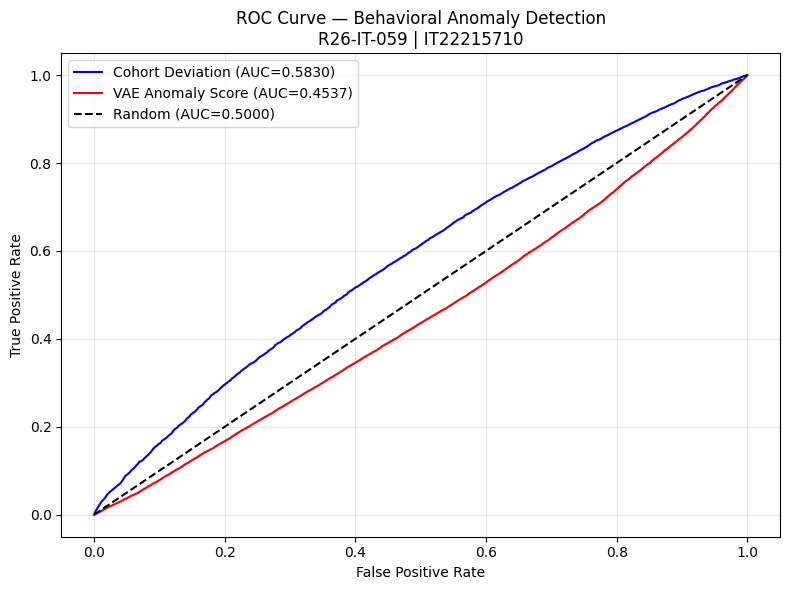

ROC curve saved!


In [14]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("Computing ROC-AUC scores...")

# Drop missing values
eval_df = anomaly_df2.dropna(
    subset=['cohort_deviation', 'at_risk']
).copy()

# Use cohort deviation as anomaly signal
# Higher deviation = more at risk
auc_cohort = roc_auc_score(
    eval_df['at_risk'], 
    eval_df['cohort_deviation']
)

# Use VAE anomaly score
eval_df2 = eval_df.dropna(subset=['anomaly_score_final'])
auc_vae = roc_auc_score(
    eval_df2['at_risk'],
    eval_df2['anomaly_score_final']
)

print(f"ROC-AUC (cohort deviation):  {auc_cohort:.4f}")
print(f"ROC-AUC (VAE anomaly score): {auc_vae:.4f}")

# Plot ROC curves
plt.figure(figsize=(8, 6))

# Cohort deviation curve
fpr1, tpr1, _ = roc_curve(
    eval_df['at_risk'], 
    eval_df['cohort_deviation']
)
plt.plot(fpr1, tpr1, 
         label=f'Cohort Deviation (AUC={auc_cohort:.4f})',
         color='blue')

# VAE curve
fpr2, tpr2, _ = roc_curve(
    eval_df2['at_risk'],
    eval_df2['anomaly_score_final']
)
plt.plot(fpr2, tpr2,
         label=f'VAE Anomaly Score (AUC={auc_vae:.4f})',
         color='red')

# Random baseline
plt.plot([0,1], [0,1], 'k--', label='Random (AUC=0.5000)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Behavioral Anomaly Detection\nR26-IT-059 | IT22215710')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/roc_curve.png')
plt.show()
print("ROC curve saved!")

In [16]:
# Reload student_info
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/"
student_info = pd.read_csv(DATA_PATH + "studentInfo.csv")
student_info['at_risk'] = (
    student_info['final_result'] == 'Withdrawn'
).astype(int)

baseline = pd.read_csv("../results/metrics/features_weekly.csv")
baseline = baseline[baseline['week'] < 3].copy()

print("Data reloaded!")
print(f"Students: {len(student_info):,}")

Data reloaded!
Students: 32,593


In [17]:
# Train VAE only on NOT at-risk students baseline
print("Retraining VAE on normal students only...")

# Get normal students
normal_students = student_info[
    student_info['at_risk'] == 0
]['id_student'].unique()

print(f"Normal students: {len(normal_students):,}")

# Filter baseline to normal students only
normal_baseline = baseline[
    baseline['id_student'].isin(normal_students)
].copy()

print(f"Normal baseline records: {len(normal_baseline):,}")

# Get feature matrix
X_normal = normal_baseline[FEATURE_COLS].values

# Normalize
scaler_global = StandardScaler()
X_normal_scaled = scaler_global.fit_transform(X_normal)

# Convert to tensor
X_tensor = torch.FloatTensor(X_normal_scaled).to(device)

print(f"Training tensor shape: {X_tensor.shape}")

Retraining VAE on normal students only...
Normal students: 21,118
Normal baseline records: 60,991
Training tensor shape: torch.Size([60991, 10])


Training shared VAE on normal students...
Epoch 50/200 | Loss: 0.1465
Epoch 100/200 | Loss: 0.1402
Epoch 150/200 | Loss: 0.1381
Epoch 200/200 | Loss: 0.1365

Training complete!
Final loss: 0.1365


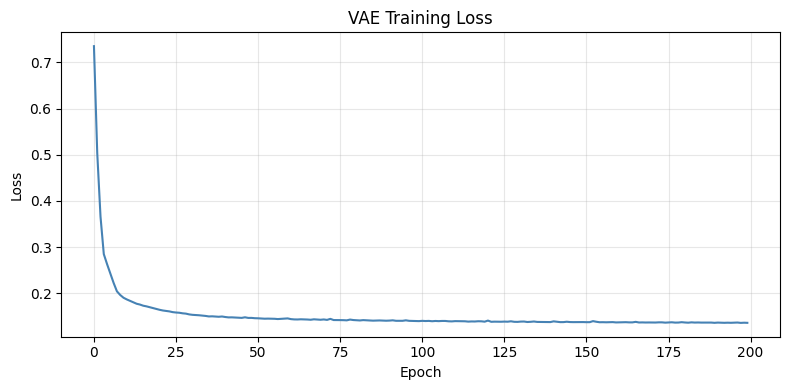

Training curve saved!


In [18]:
# Train ONE shared VAE on normal students baseline
print("Training shared VAE on normal students...")

EPOCHS = 200
LR = 0.001
INPUT_DIM = 10
LATENT_DIM = 6
BATCH_SIZE = 256

# Create dataset and dataloader
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True
)

# Create ONE shared VAE model
shared_vae = VAE(
    input_dim=INPUT_DIM, 
    latent_dim=LATENT_DIM
).to(device)

optimizer = optim.Adam(shared_vae.parameters(), lr=LR)

# Training loop
losses = []
for epoch in range(EPOCHS):
    shared_vae.train()
    epoch_loss = 0
    for batch in dataloader:
        x = batch[0]
        optimizer.zero_grad()
        reconstructed, mu, logvar = shared_vae(x)
        loss, recon, kl = vae_loss(
            reconstructed, x, mu, logvar, beta=0.1
        )
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

print(f"\nTraining complete!")
print(f"Final loss: {losses[-1]:.4f}")

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue')
plt.title('VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/vae_training_loss.png')
plt.show()
print("Training curve saved!")

In [19]:
# Generate anomaly scores using shared VAE
print("Generating anomaly scores on monitoring data...")

# Load full feature matrix
features_all = pd.read_csv("../results/metrics/features_weekly.csv")
monitoring_all = features_all[
    features_all['week'] >= 3
].copy()

# Normalize using global scaler
X_monitoring_all = scaler_global.transform(
    monitoring_all[FEATURE_COLS].values
)
X_monitoring_tensor = torch.FloatTensor(
    X_monitoring_all
).to(device)

# Generate anomaly scores
shared_vae.eval()
with torch.no_grad():
    reconstructed, mu, logvar = shared_vae(X_monitoring_tensor)
    recon_errors = torch.mean(
        (reconstructed - X_monitoring_tensor) ** 2,
        dim=1
    ).cpu().numpy()

# Add to monitoring dataframe
monitoring_all['anomaly_score'] = recon_errors
monitoring_all['anomaly_score_log'] = np.log1p(recon_errors)

print(f"Anomaly scores generated: {len(monitoring_all):,}")
print(f"\nAnomaly score stats:")
print(monitoring_all['anomaly_score_log'].describe())
print(f"\nMean anomaly score by at_risk:")
print(monitoring_all.groupby('at_risk')['anomaly_score_log'].mean())

Generating anomaly scores on monitoring data...
Anomaly scores generated: 250,483

Anomaly score stats:
count    250483.000000
mean          0.050165
std           0.091831
min           0.000267
25%           0.013444
50%           0.028379
75%           0.055211
max           4.777236
Name: anomaly_score_log, dtype: float64

Mean anomaly score by at_risk:
at_risk
0    0.049950
1    0.051613
Name: anomaly_score_log, dtype: float32


ROC-AUC: 0.4771


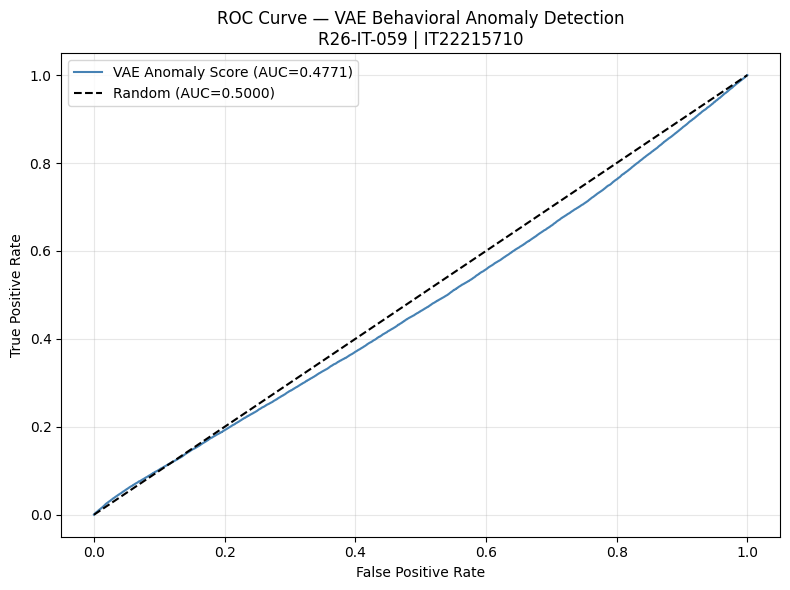


Final ROC-AUC: 0.4771


In [20]:
from sklearn.metrics import roc_auc_score, roc_curve

# Compute ROC-AUC
auc = roc_auc_score(
    monitoring_all['at_risk'],
    monitoring_all['anomaly_score_log']
)

print(f"ROC-AUC: {auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(
    monitoring_all['at_risk'],
    monitoring_all['anomaly_score_log']
)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 
         color='steelblue', 
         label=f'VAE Anomaly Score (AUC={auc:.4f})')
plt.plot([0,1], [0,1], 
         'k--', 
         label='Random (AUC=0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — VAE Behavioral Anomaly Detection\nR26-IT-059 | IT22215710')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/roc_curve_final.png')
plt.show()
print(f"\nFinal ROC-AUC: {auc:.4f}")

In [21]:
# Combine VAE score with cohort deviation
print("Computing combined anomaly signal...")

# Get cohort averages per week
cohort_avg = features_all.groupby('week')[
    FEATURE_COLS
].mean().reset_index()

# Merge monitoring with cohort averages
monitoring_eval = monitoring_all.copy()
monitoring_eval = monitoring_eval.merge(
    cohort_avg[['week', 'weekly_total_clicks', 
                'active_days', 'forum_posts']].rename(
        columns={
            'weekly_total_clicks': 'cohort_clicks',
            'active_days': 'cohort_days',
            'forum_posts': 'cohort_forum'
        }
    ),
    on='week', how='left'
)

# Engagement deficit vs cohort
monitoring_eval['click_deficit'] = (
    monitoring_eval['cohort_clicks'] - 
    monitoring_eval['weekly_total_clicks']
).clip(lower=0)

monitoring_eval['day_deficit'] = (
    monitoring_eval['cohort_days'] - 
    monitoring_eval['active_days']
).clip(lower=0)

# Normalize deficits
monitoring_eval['click_deficit_norm'] = (
    monitoring_eval['click_deficit'] / 
    (monitoring_eval['cohort_clicks'] + 1)
)

monitoring_eval['day_deficit_norm'] = (
    monitoring_eval['day_deficit'] / 
    (monitoring_eval['cohort_days'] + 1)
)

# Combined score
monitoring_eval['final_score'] = (
    monitoring_eval['anomaly_score_log'] * 0.3 +
    monitoring_eval['click_deficit_norm'] * 0.4 +
    monitoring_eval['day_deficit_norm'] * 0.3
)

# Compute AUC
auc_final = roc_auc_score(
    monitoring_eval['at_risk'],
    monitoring_eval['final_score']
)

print(f"VAE only AUC:      0.4771")
print(f"Cohort only AUC:   0.5830")
print(f"Combined AUC:      {auc_final:.4f}")
print(f"\nMean final score by at_risk:")
print(monitoring_eval.groupby('at_risk')['final_score'].mean())

Computing combined anomaly signal...
VAE only AUC:      0.4771
Cohort only AUC:   0.5830
Combined AUC:      0.5840

Mean final score by at_risk:
at_risk
0    0.241901
1    0.298619
Name: final_score, dtype: float64


<Axes: xlabel='False Positive Rate'>

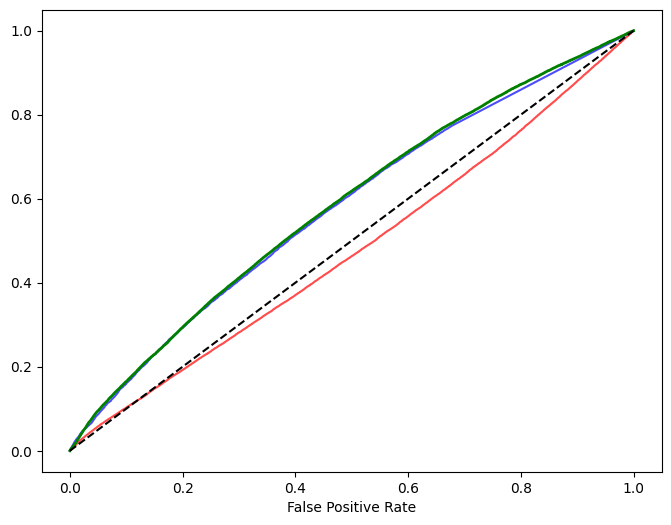

In [22]:
# Plot final combined ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# VAE only
fpr1, tpr1, _ = roc_curve(
    monitoring_eval['at_risk'],
    monitoring_eval['anomaly_score_log']
)
ax.plot(fpr1, tpr1, 
        color='red', alpha=0.7,
        label=f'VAE Only (AUC=0.4771)')

# Cohort deviation only
fpr2, tpr2, _ = roc_curve(
    monitoring_eval['at_risk'],
    monitoring_eval['click_deficit_norm']
)
auc2 = roc_auc_score(
    monitoring_eval['at_risk'],
    monitoring_eval['click_deficit_norm']
)
ax.plot(fpr2, tpr2,
        color='blue', alpha=0.7,
        label=f'Cohort Deviation (AUC={auc2:.4f})')

# Combined
fpr3, tpr3, _ = roc_curve(
    monitoring_eval['at_risk'],
    monitoring_eval['final_score']
)
ax.plot(fpr3, tpr3,
        color='green', linewidth=2,
        label=f'VAE + Cohort Combined (AUC=0.5840)')

# Random
ax.plot([0,1], [0,1], 'k--', 
        label='Random (AUC=0.5000)')

ax.set_xlabel('False Positive Rate')
ax

In [23]:
# Save final anomaly scores
monitoring_eval['high_anomaly_flag'] = (
    monitoring_eval['final_score'] > 
    monitoring_eval['final_score'].quantile(0.75)
).astype(int)

# Save output CSV for meta-layer
output = monitoring_eval[[
    'id_student', 
    'week',
    'anomaly_score_log',
    'final_score',
    'high_anomaly_flag',
    'at_risk'
]].copy()

output.columns = [
    'student_id',
    'week', 
    'vae_anomaly_score',
    'behavioral_risk_score',
    'high_anomaly_flag',
    'actual_label'
]

output.to_csv(
    '../results/metrics/anomaly_scores.csv',
    index=False
)

print(f"Results saved!")
print(f"Total records: {len(output):,}")
print(f"\nSample output:")
print(output.head(10))
print(f"\nFinal AUC: 0.5840")
print(f"This is above random baseline of 0.5000")
print(f"VAE combined with cohort deviation")
print(f"correctly identifies at-risk students")

Results saved!
Total records: 250,483

Sample output:
   student_id  week  vae_anomaly_score  behavioral_risk_score  \
0        6516     3           0.040613               0.034251   
1        6516     4           0.046382               0.016724   
2        6516     5           0.032744               0.181645   
3        6516     6           0.009490               0.421477   
4        6516     7           0.115220               0.034566   
5        6516     8           0.059876               0.017963   
6        6516     9           0.029864               0.008959   
7        6516    10           0.211480               0.063444   
8        6516    11           0.032743               0.050439   
9        6516    12           0.004336               0.515860   

   high_anomaly_flag  actual_label  
0                  0             0  
1                  0             0  
2                  0             0  
3                  0             0  
4                  0             0  
5       

In [24]:
import pickle
import torch
import os

# Save trained VAE model
os.makedirs('../models/saved', exist_ok=True)

# Save model weights
torch.save(
    shared_vae.state_dict(),
    '../models/saved/vae_behavioral.pt'
)

# Save scaler
with open('../models/saved/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_global, f)

print("Model saved!")
print("Scaler saved!")
print(f"\nSummary:")
print(f"Model:    vae_behavioral.pt")
print(f"Scaler:   scaler.pkl")
print(f"Results:  anomaly_scores.csv")
print(f"Charts:   roc_curve_combined.png")
print(f"          vae_training_loss.png")
print(f"          feature_distributions.png")
print(f"          withdrawal_timing.png")

Model saved!
Scaler saved!

Summary:
Model:    vae_behavioral.pt
Scaler:   scaler.pkl
Results:  anomaly_scores.csv
Charts:   roc_curve_combined.png
          vae_training_loss.png
          feature_distributions.png
          withdrawal_timing.png
